In [2]:
# 1. 파이썬 코드에서 Matplotlib 폰트 설정
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from datetime import timedelta
from itertools import combinations
from collections import Counter

# 폰트 설정
plt.rc('font', family='Malgun Gothic')
# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print("한글 폰트 설정이 완료되었습니다.")

# 3. 데이터 로드 및 통합 (모든 문제 풀이의 시작점)
try:
    orders_df = pd.read_csv('../data/orders.csv')
    payments_df = pd.read_csv('../data/payments.csv')
    products_df = pd.read_csv('../data/products.csv')
    shipping_df = pd.read_csv('../data/shipping.csv')
    customers_df = pd.read_csv('../data/customers.csv')

    # 모든 데이터프레임 병합
    df = pd.merge(orders_df, payments_df, on='order_id', how='left')
    df = pd.merge(df, products_df, on='product_id', how='left')
    df = pd.merge(df, customers_df, on='customer_id', how='left')
    df = pd.merge(df, shipping_df, on='order_id', how='left')

    # 데이터 전처리
    date_cols = ['order_date', 'payment_date', 'join_date', 'shipping_start_date', 'shipping_end_date']
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors='coerce')
    df['total_sales'] = df['quantity'] * df['price']
    
    print("데이터 로드 및 통합이 완료되었습니다.")

except FileNotFoundError as e:
    print(f"파일을 찾을 수 없습니다: {e}")


한글 폰트 설정이 완료되었습니다.
데이터 로드 및 통합이 완료되었습니다.


In [3]:
# 문제 8: 고객이 주로 활동하는 상위 15개 도시를 파악하고, 도시별 고객 수와 총매출액을 비교하세요.
# 시각화: 바 차트 (이중 축)

# 비즈니스 목적: 지역 기반 마케팅 전략을 수립하고, 특정 도시에 오프라인 매장을 열거나 지역 광고를 집행할 때의 의사결정 근거로 활용합니다.

# 출력 결과를 보고 코딩하세요



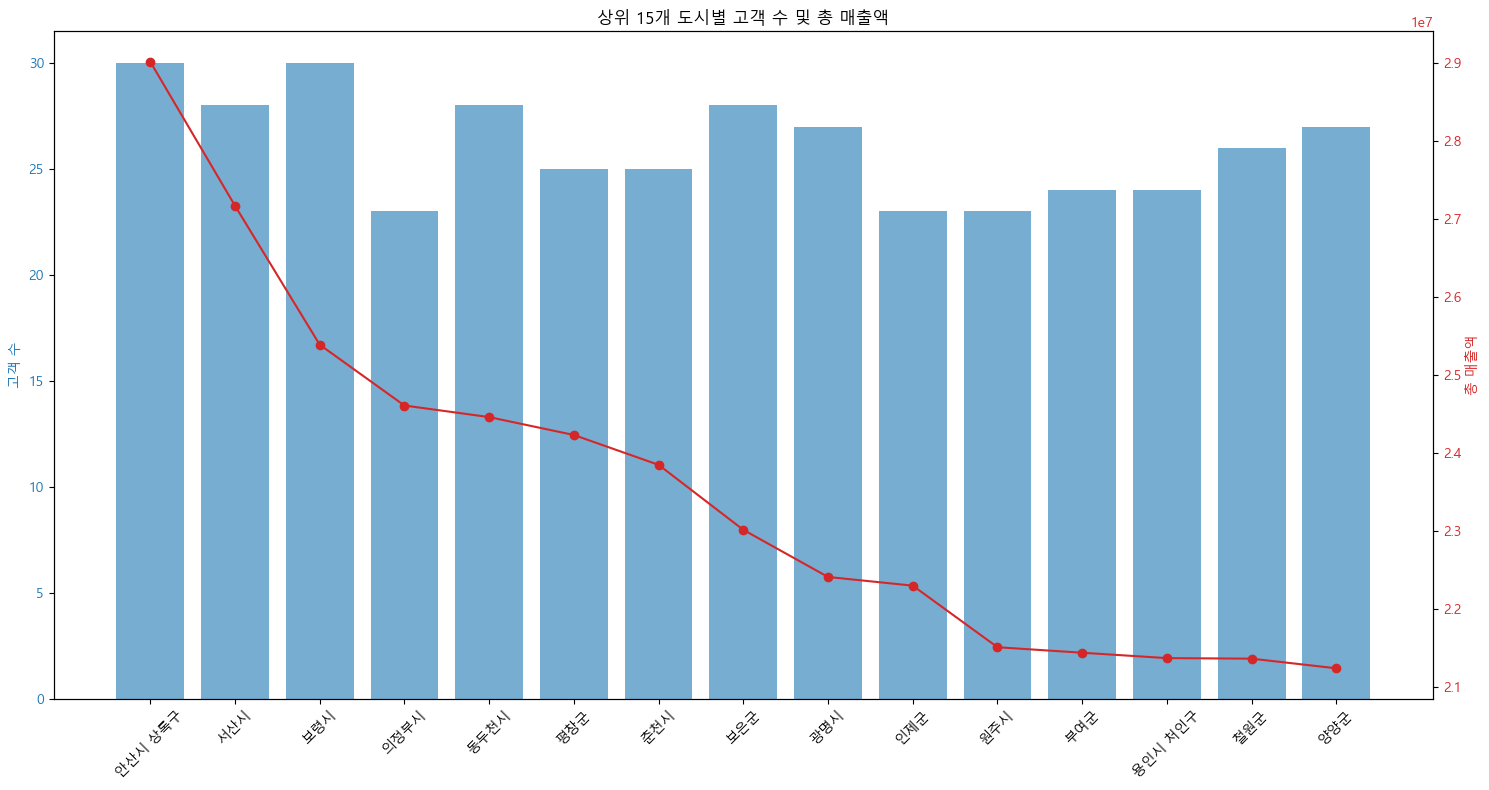



In [4]:
# ============================================================
# [계산 블록: 실제 컬럼명을 사용한 실무형 집계]
# - 전제: df는 이미 기존에 너가 합쳐둔 통합 DataFrame (orders+payments+products+customers+shipping)
# - 너가 준 컬럼 목록(예: 'city', 'customer_id', 'total_sales')을 그대로 사용함
# ============================================================

# --------------------------------------------
# 0) 필요한 컬럼(명시) - 너가 처음 보낸 리스트와 동일
# city          : 고객 도시 (문자열 / string)  — 발음: '시-티'
# customer_id   : 고객 고유 ID (식별키 / ID)      — 발음: '커스터머 아이디'
# total_sales   : 주문별 총 매출 (quantity * price) — 발음: '토털-세일즈'
# order_id      : 주문 고유번호 (필요 시 집계용)   — 발음: '오더 아이디'
# --------------------------------------------

# -------------------------
# 1) 컬럼 존재 여부 확인 (defensive check)
# - 실무에서는 항상 필요한 컬럼이 있는지 확인 후 진행해야 오류 방지
required = ['city', 'customer_id', 'total_sales']
missing = [c for c in required if c not in df.columns]  # list comprehension: 리스트 내포 (발음: '리스트 컴-프리헨션')
if missing:
    raise KeyError(f"필요 컬럼 누락: {missing}  — df.columns: {list(df.columns)}")
# 이유: 없는 컬럼으로 연산하면 KeyError 발생하므로 조기 실패(fail fast) 처리.

# -------------------------
# 2) 도시별 고유 고객 수 계산
# - groupby: 특정 컬럼으로 묶는 함수 (발음: '그룹-바이')
# - nunique: 고유값 개수 (unique count) (발음: '엔-유-니크')
city_customer = (
    df
    .groupby('city', as_index=False)                  # as_index=False: 그룹 컬럼을 인덱스로 만들지 않음
    .agg(unique_customers=('customer_id', 'nunique'))# agg: aggregation(집계) / 발음: '어그리게이션'
)
# 결과: DataFrame with columns ['city', 'unique_customers']

# -------------------------
# 3) 도시별 총매출(total_sales 합) 계산
# - sum: 합계 (발음: '섬')
city_revenue = (
    df
    .groupby('city', as_index=False)
    .agg(total_revenue=('total_sales', 'sum'))      # 총매출 합계를 total_revenue로 저장
)
# 결과: DataFrame with columns ['city', 'total_revenue']

# -------------------------
# 4) 고객수와 매출 병합(merge)
# - merge: SQL의 JOIN과 동일 (발음: '머지')
city_summary = pd.merge(city_customer, city_revenue, on='city', how='inner')
# 이유: 하나의 테이블에 고객수와 매출을 합쳐야 이후 정렬/선택/시각화가 쉬움

# -------------------------
# 5) 추가 실무 지표(선택적) - 주문 수, 평균 주문액 등 (있으면 계산)
# - order_cnt: 도시별 주문 건수 (order_id의 고유 개수)
if 'order_id' in df.columns:
    order_cnt = (
        df
        .groupby('city', as_index=False)
        .agg(order_cnt=('order_id', 'nunique'))   # 주문 건수 (unique 주문 개수)
    )
    # merge로 city_summary에 추가
    city_summary = pd.merge(city_summary, order_cnt, on='city', how='left')

# -------------------------
# 6) 상위 15개 도시 자동 선정 (정렬 기준: 총매출 total_revenue)
# - sort_values: 값 기준 정렬 (발음: '소트-벨류즈')
# - ascending=False: 내림차순
top15 = (
    city_summary
    .sort_values(by='total_revenue', ascending=False)  # 매출 많은 순서대로 정렬
    .head(15)                                          # 상위 15개 선택
    .reset_index(drop=True)                            # 인덱스 리셋 (보고/시각화 편의)
)

# -------------------------
# 7) (확인) 결과 출력 - 실무에서는 로깅이나 파일로 저장
print("=== 상위 15개 도시 요약 (매출 기준 내림차순) ===")
print(top15)  # DataFrame 출력: columns 예시 ['city','unique_customers','total_revenue', 'order_cnt'(선택적)]


=== 상위 15개 도시 요약 (매출 기준 내림차순) ===
       city  unique_customers  total_revenue  order_cnt
0   안산시 상록구                30       29023200        163
1       서산시                28       27176000        153
2       보령시                30       25393100        153
3      의정부시                23       24612900        130
4      동두천시                28       24464300        149
5       평창군                25       24234900        125
6       춘천시                25       23852100        147
7       보은군                28       23018300        137
8       광명시                27       22413700        132
9       인제군                23       22302400        134
10      원주시                23       21512700        124
11      부여군                24       21441900        130
12  용인시 처인구                24       21372900        129
13      철원군                26       21365900        127
14      양양군                27       21242200        125


C:\Users\TJ\AppData\Local\Temp\ipykernel_17756\2164869267.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


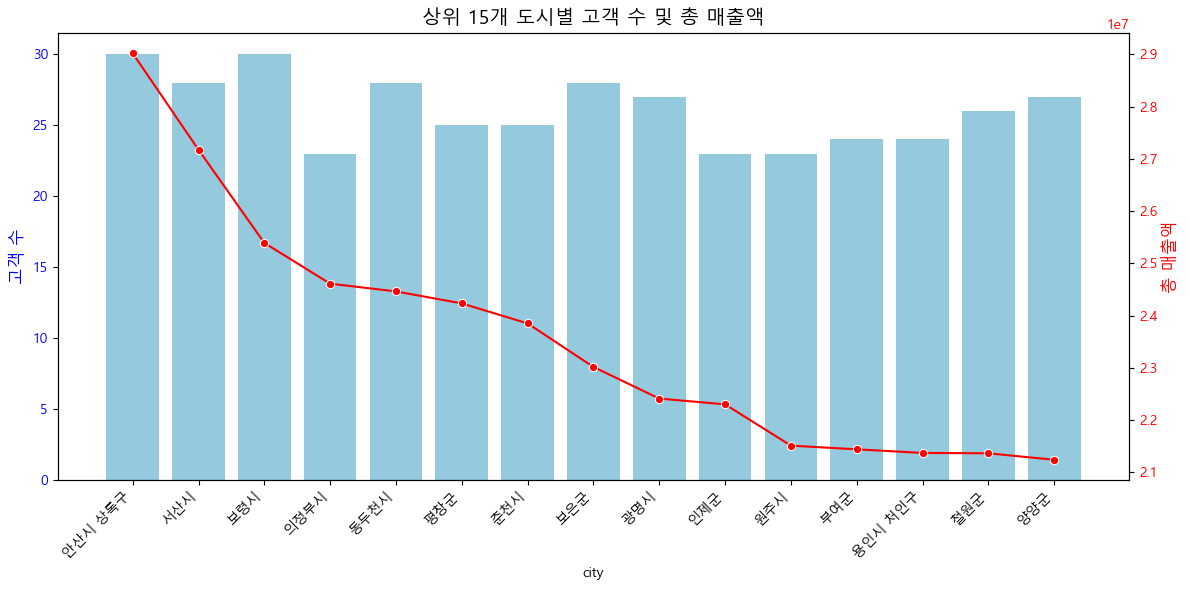

In [14]:
# 1. 도시별 고객 수 (고객 중복 제거)
city_customers = df[['customer_id', 'city']].drop_duplicates()
city_customer_count = city_customers.groupby('city')['customer_id'].count().reset_index()
city_customer_count.rename(columns={'customer_id': 'customer_count'}, inplace=True)


# 2. 도시별 총매출액
city_sales = df.groupby('city')['total_sales'].sum().reset_index()


# 3. 병합
city_summary = pd.merge(city_customer_count, city_sales, on='city')


# 4. 상위 15개 도시 (매출 기준)
top_cities = city_summary.sort_values('total_sales', ascending=False).head(15)


# 5. 시각화
fig, ax1 = plt.subplots(figsize=(12,6))


# 고객 수 막대 (왼쪽 y축)
sns.barplot(data=top_cities, x='city', y='customer_count', color='skyblue', ax=ax1)
ax1.set_ylabel('고객 수', fontsize=12, color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


# 매출액 선 그래프 (오른쪽 y축)
ax2 = ax1.twinx()
sns.lineplot(data=top_cities, x='city', y='total_sales', color='red', marker='o', ax=ax2)
ax2.set_ylabel('총 매출액', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')


plt.title("상위 15개 도시별 고객 수 및 총 매출액", fontsize=14)
plt.tight_layout()
plt.show()



In [6]:
# 🧩 2️⃣ columns: 내용 분석

# 지금 이 리스트는 df 안의 모든 컬럼(속성) 이름이에요.

# 컬럼 이름	역할 설명
# order_id	주문 고유번호
# customer_id	고객 고유번호
# product_id	제품 고유번호
# order_date	주문한 날짜
# quantity	주문 수량
# payment_method	결제 방식 (카드, 계좌이체 등)
# payment_status	결제 상태 (완료, 취소 등)
# payment_date	결제일
# product_name	제품 이름
# category	상품 카테고리
# price	상품 가격 (단가)
# stock	재고 수량
# name	고객 이름
# gender	고객 성별
# age	고객 나이
# join_date	고객 가입일
# city	고객 도시
# shipping_id	배송 고유번호
# shipping_company	배송사 이름
# shipping_status	배송 상태
# shipping_start_date	배송 시작일
# shipping_end_date	배송 완료일
# total_sales	총 주문 금액 (quantity × price) — ✅ 우리가 분석에 쓸 핵심 컬럼
# age_group	연령대 (예: 10대, 20대 …) — ✅ 히트맵 만들 때 꼭 필요